# Exam

> Data: **2023-07-07**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Il datataset (preso e modificato da [Kaggle](https://www.kaggle.com/datasets/rishikeshkonapure/home-loan-approval) contiene dati relativi a persone che sono riuscite a estinguere il prestito (Loan_Status).

Note: Il file csv che si trova al [link](https://bit.ly/2023BDTA1).

> **Note personali.**
>
> Nel dataset di Kaggle `Loan_Status` riguarda l'ottenimento o meno del prestito, ovvero se la richiesta è stata approvata o meno. Quindi, molto probabilmente, la classificazione riguarda l'approvazione del prestito più che alla restituzione come in molte domande del testo.
>
> Laddove necessario, il testo viene modificato con <s>una riga sul testo</s> in modo da sapere cosa viene modificato, mentre la correzione al testo è mostrata <u>come sottolineato</u>.

### Imports

In [1]:
!curl -sLo dataset.csv "https://sparc20.ing.unimo.it/~guerra/esamiBDA/loan_sanction_train.csv"
# !unzip -o dataset.zip
# !mv file.csv dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

In [74]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

### Dataset

In [3]:
df = pd.read_csv("dataset.csv")

#### Overview

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


#### Instances

In [6]:
df.shape

(614, 13)

#### Missing values

In [7]:
df.isnull().sum().sum()

np.int64(149)

#### Balancing

In [8]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


<Axes: >

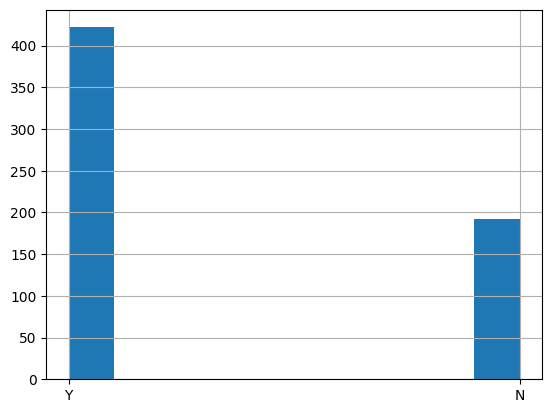

In [9]:
df["Loan_Status"].hist()

##

---

## Parte 1: Analisi (Punti 10)

### Domanda 01 (Punti 1)

Quante sono le istanze contenute nel dataset? Il dataset è completo (cioè per ogni istanza tutti i valori di ogni attributo sono sempre correttamente specificati - non esistono "missing values")? Il dataset è bilanciato per quanto riguarda la classe da predire?

In [10]:
df.shape[0]

614

> Il dataset contiene 614 istanze.

In [11]:
df.isnull().sum().sum()

np.int64(149)

> Il dataset non è completo, in quanto sono presenti un totale di 149 missing values.

In [12]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


> Il dataset non è bilanciato, in quanto sono presenti 422 istanze della classe `Y` contro le 192 istanze della classe `N`.

---

### Domanda 02 (Punti 4)

Verificare se in generale le persone con la laurea (Education = "Graduate") hanno più difficoltà a <s>restituire</s> <u>ottenere</u> il prestito rispetto a quelle senza. Realizzare una pivot table attraverso la quale mostrare quanti sono gli uomini / donne (sulle righe), con / senza laurea (colonne) e individuare per ognuna di queste categorie la percentuale di persone che non sono in grado di <s>restituire</s> <u>ottenere</u> il prestito. L'essere laureato incide diversamente nei due generi?

In [13]:
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})
df.groupby("Education")["Loan_Status"].mean()

,Loan_Status
Education,
Graduate,0.708333
Not Graduate,0.611940


> No, sembrerebbe che le persone non laureate facciano più fatica a farsi approvare un prestito, in quanto la percentuale di prestiti accettati è minore per i non laureati.

In [14]:
df.pivot_table(index="Gender", columns="Education", values="Loan_Status", aggfunc="mean")

Education,Graduate,Not Graduate
Gender,,
Female,0.663043,0.70000
Male,0.720745,0.60177


> Dalla tabella pivot possiamo notare come la percentuale di prestiti approvati sia maggiore per i maschi laureati, mentre la percentuale minore di prestiti approvati riguarda alle femmine non laureate.
>
> Quindi sembrerebbe che la laurea incida in modo opposto per i due generi.

---

### Domanda 03 (Punti 3)

Ci si aspetta che l'ammontare del prestito (LoanAmount) concesso abbia una qualche relazione con la durata del prestito (Loan_Amount_Term). Calcolare il rapporto tra le due grandezze e fare un grafico della distribuzione dei valori.

In [15]:
mask_approved = df["Loan_Status"] == 1
df["Loan_Amount_Ratio"] = (df["LoanAmount"] * 1000) / df["Loan_Amount_Term"]
ratio_df = df[mask_approved]["Loan_Amount_Ratio"].dropna()
bins=30

In [16]:
ratio_bins = pd.cut(ratio_df, bins=bins).value_counts()
ratio_bins[ratio_bins > 0]

,count
Loan_Amount_Ratio,
"(63.044, 378.148]",227
"(378.148, 684.074]",124
"(684.074, 990.0]",27
"(990.0, 1295.926]",12
"(1295.926, 1601.852]",5
"(1601.852, 1907.778]",2
"(2519.63, 2825.556]",2
"(1907.778, 2213.704]",1
"(2213.704, 2519.63]",1


<Axes: xlabel='Ratio €/month', ylabel='Frequency'>

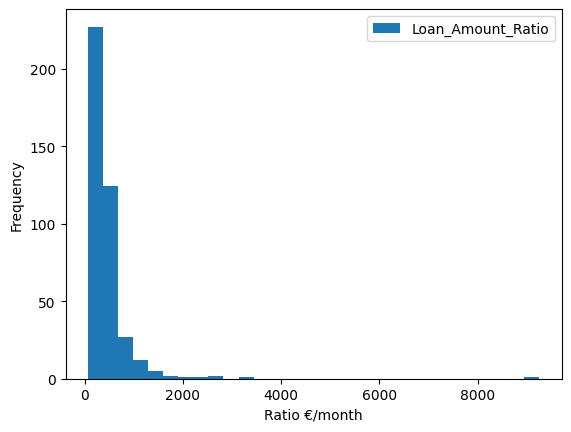

In [17]:
ratio_df.plot(kind="hist", bins=bins, xlabel="Ratio €/month", legend=True)

> Come possiamo notare dall'istogramma, praticamente tutti i prestiti approvati hanno un pagamento mensile tra i 60 e i 685€, di cui 227 fino a 380€ e 124 fino a 685€.

---

### Domanda 04 (Punti 2)

Ci si aspetta che sia più difficile <s>restituire</s> <u>ottenere</u> prestiti con durata più limitata. Questa intuizione è in qualche modo supportata dai dati? Motivare la risposta.

<Axes: xlabel='Loan_Amount_Term'>

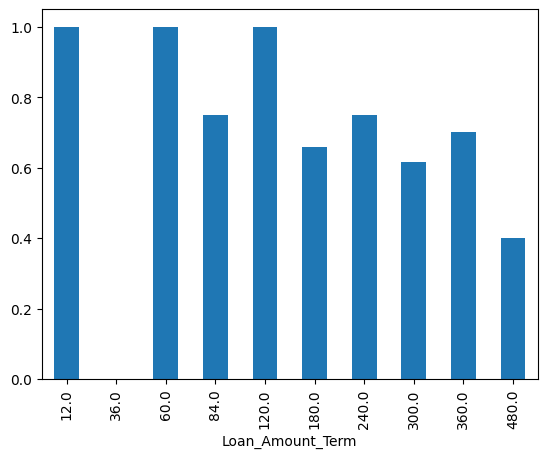

In [18]:
df.groupby("Loan_Amount_Term")["Loan_Status"].mean().plot(kind="bar")

> No, i prestiti con una durata più limitata sembrano in percentuale più facilmente approvabili, mentre più si allunga l'orizzonte temporale del prestito, più sembra difficile farselo approvare e quindi ottenere.

##

---

## Parte 2: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 3)

Si vuole predire il valore di Loan_Status sulla base degli attributi presenti nel dataset. Ricaricare il dataset originale, eliminare eventuali attributi inutili (giustificare la scelta), eliminare le istanze che contengono valori nulli, rendere tutti gli attributi numerici, e dividerlo in modo che 3/4 degli elementi siano contenuti in un nuovo dataset "train" e 1/4 nel dataset "test".

Allenare il train con il modello Decision Tree e valutare l'accuracy ottenuta calcolata sia sul dataset train sia sul dataset test. Confrontare i risultati ottenuti con quelli ottenuti con una predizione basata sul modello KNeighborsClassifier. Effettuare alcune considerazioni sui risultati ottenuti, tenendo in considerazione anche l'analisi della confusion matrix e la predizione effettuata da un dummy classifier.

In [19]:
df = pd.read_csv("dataset.csv")
df.drop("Loan_ID", axis=1, inplace=True)
df.dropna(inplace=True)
categorical_columns = df.select_dtypes(include="object")
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
df[categorical_columns.columns] = encoder.fit_transform(categorical_columns)
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
5,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [20]:
X, y = df.drop("Loan_Status", axis=1), df["Loan_Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [21]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=0),
    "KNeighbors": KNeighborsClassifier(),
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(f"{name}:")
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_pred_train))
    print("    F1-score:", f1_score(y_train, y_pred_train))
    print(confusion_matrix(y_train, y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_pred_test))
    print("    F1-score:", f1_score(y_test, y_pred_test))
    print(confusion_matrix(y_test, y_pred_test))
    print("=" * 30)
    print()

DecisionTree:
TRAIN
    Accuracy: 1.0
    F1-score: 1.0
[[111   0]
 [  0 249]]
------------------------------
TEST
    Accuracy: 0.6666666666666666
    F1-score: 0.7530864197530864
[[19 18]
 [22 61]]

KNeighbors:
TRAIN
    Accuracy: 0.7472222222222222
    F1-score: 0.836036036036036
[[ 37  74]
 [ 17 232]]
------------------------------
TEST
    Accuracy: 0.675
    F1-score: 0.7821229050279329
[[11 26]
 [13 70]]

Dummy:
TRAIN
    Accuracy: 0.6916666666666667
    F1-score: 0.8177339901477833
[[  0 111]
 [  0 249]]
------------------------------
TEST
    Accuracy: 0.6916666666666667
    F1-score: 0.8177339901477833
[[ 0 37]
 [ 0 83]]



> I modelli lavorano discretamente bene se si considera la metrica di F1, in quanto il dataset non risultava bilanciato. Il modello che lavora leggermente meglio è il `KNeighbors`, con 78% di F1, contro il 75% del `DecisionTree`. Il modello `Dummy` è stato impostato per predire la classe con più frequenza nel dataset, e dato che il dataset è sbilanciato, mostra performance abbastanza elevate, ma le sue predizioni sono effettuate a priori.

---

### Domanda 02 (Punti 4)

Trovare i parametri migliori del classificatore DecisionTree. Agire sui parametri criterion e min_samples_leaf. Verificare se l'accuratezza che si ottiene con la nuova configurazione supera quella con i parametri di default ottenuta al punto 1.

In [22]:
decision_tree = models["DecisionTree"]

params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50, 100],
}
grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params: {'criterion': 'entropy', 'min_samples_leaf': 20}
Best score: 0.8055555555555557
Accuracy: 0.8083333333333333
F1-score: 0.8743169398907104
[[17 20]
 [ 3 80]]


> Notiamo immediatamente come l'utilizzo del `GridSearchCV` per trovare i parametri ottimali `criterion` e `min_samples_leaf` del modello `DecisionTree`, con valori ottimali rispettivamente `entropy` e `20`, abbia portato a un incremento delle performance, arrivando a un F1 di 87%.
>
> La classe che il modello sbaglia maggiormente a predire è la classe 0, ovvero la non approvazione del prestito. Il modello ha approvato 20 prestiti che in realà non erano stati approvati.

---

### Domanda 03 (Punti 5)

Valutare la demographic parity del classificatore Decision Tree rispetto al valore di Education, ovvero se la probabilità di predire 0 è la stessa nelle persone laureate e non laureate. Valutare l'equalized odds, ovvero se l'accuratezza ottenuta nelle persone laureate è la stessa ottenuta nelle persone non laureate. Eliminare l'attributo Education dal train e valutare se se l'accuratezza ottenuta nelle persone laureate è la stessa ottenuta nelle persone non laureate.

In [23]:
mask_graduate = X_test["Education"] == 0
mask_not_graduate = X_test["Education"] == 1
mask_not_approved = y_pred == 0

probability_graduate_not_approved = y_pred[mask_graduate & mask_not_approved].shape[0] / y_pred[mask_graduate].shape[0]
probability_not_graduate_not_approved = y_pred[mask_not_graduate & mask_not_approved].shape[0] / y_pred[mask_not_graduate].shape[0]

print("Probability of not approving a loan given a graduate:", probability_graduate_not_approved)
print("Probability of not approving a loan given a non-graduate:", probability_not_graduate_not_approved)

Probability of not approving a loan given a graduate: 0.15217391304347827
Probability of not approving a loan given a non-graduate: 0.21428571428571427


> La probabilità di non ottenere un prestito da parte di una persona laureata risulta essere un pelo più bassa rispetto a una persona non laureata secondo le predizioni effettuate dal modello.

In [24]:
probability_graduate_approved = y_pred[mask_graduate].sum() / y_pred[mask_graduate].shape[0]
probability_not_graduate_approved = y_pred[mask_not_graduate].sum() / y_pred[mask_not_graduate].shape[0]

print("Probability of approving a loan given a graduate:", probability_graduate_approved)
print("Probability of approving a loan given a non-graduate:", probability_not_graduate_approved)

min_probability = min(probability_graduate_approved, probability_not_graduate_approved)
max_probability = max(probability_graduate_approved, probability_not_graduate_approved)
print("Demographic parity ratio:", min_probability / max_probability)

Probability of approving a loan given a graduate: 0.8478260869565217
Probability of approving a loan given a non-graduate: 0.7857142857142857
Demographic parity ratio: 0.9267399267399268


> Il Demographic Parity Ratio risulta comunque abbastanza vicino a 1, ciò vuole dire che il modello predice in modo abbastanza equo rispetto le due classi.

In [25]:
print("Performance of not approving a loan given a graduate:", f1_score(y_test[mask_graduate], y_pred[mask_graduate]))
print("Performance of not approving a loan given a non-graduate:", f1_score(y_test[mask_not_graduate], y_pred[mask_not_graduate]))

Performance of not approving a loan given a graduate: 0.8671328671328671
Performance of not approving a loan given a non-graduate: 0.9


> L'equità del modello la si può vedere anche dalla valutazione delle metriche di accuratezza, in quanto non sono troppo diverse tra loro. Un altro indice dell'equità da parte del modello sulle due classi.

In [26]:
X, y = df.drop(["Loan_Status", "Education"], axis=1), df["Loan_Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [27]:
best_criterion = grid_search.best_params_["criterion"]
best_min_samples_leaf = grid_search.best_params_["min_samples_leaf"]
decision_tree = DecisionTreeClassifier(criterion=best_criterion, min_samples_leaf=best_min_samples_leaf, random_state=0)

decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8083333333333333
F1-score: 0.8743169398907104
[[17 20]
 [ 3 80]]


In [28]:
print("Performance of not approving a loan given a graduate:", f1_score(y_test[mask_graduate], y_pred[mask_graduate]))
print("Performance of not approving a loan given a non-graduate:", f1_score(y_test[mask_not_graduate], y_pred[mask_not_graduate]))

Performance of not approving a loan given a graduate: 0.8671328671328671
Performance of not approving a loan given a non-graduate: 0.9


In [29]:
probability_graduate_approved = y_pred[mask_graduate].sum() / y_pred[mask_graduate].shape[0]
probability_not_graduate_approved = y_pred[mask_not_graduate].sum() / y_pred[mask_not_graduate].shape[0]

print("Probability of approving a loan given a graduate:", probability_graduate_approved)
print("Probability of approving a loan given a non-graduate:", probability_not_graduate_approved)

min_probability = min(probability_graduate_approved, probability_not_graduate_approved)
max_probability = max(probability_graduate_approved, probability_not_graduate_approved)
print("Demographic parity ratio:", min_probability / max_probability)

Probability of approving a loan given a graduate: 0.8478260869565217
Probability of approving a loan given a non-graduate: 0.7857142857142857
Demographic parity ratio: 0.9267399267399268


> Analizzando il modello addestrato sul dataset in assenza dell'attributo `Education` possiamo notare come le performance rimangano pressoché invariate, come mostrato anche dalla valutazione del DPR e F1 sulle singole classi. Questo vuole dire che il modello non effettua predizioni basandosi sull'attributo `Education`, ovvero in presenza o meno di laurea.

---

### Domanda 04 (Punti 3)

Creare una pipeline che a partire dal dataset iniziale (dopo aver tolto le colonne rimosse al punto 1 e le colonne testuali):

- usi il Simplelmputer per inserire i valori nulli
- divida in 10 bins i valori di LoanAmount
- applichi il DecisionTreeClassifier per effettuare la predizione

In [52]:
df = pd.read_csv("dataset.csv")
df.drop(["Loan_ID"], axis=1, inplace=True)
categorical_columns = df.select_dtypes(include="object")
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[categorical_columns.columns] = encoder.fit_transform(categorical_columns)

In [54]:
X, y = df.drop("Loan_Status", axis=1), df["Loan_Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [55]:
discretizer = KBinsDiscretizer(n_bins=10, random_state=0)

column_transformer = ColumnTransformer(
    transformers=[
        ("discretizer", discretizer, X.columns.get_indexer(["LoanAmount"])),
    ],
    remainder="passthrough",
)
column_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('discretizer',
                                 KBinsDiscretizer(n_bins=10, random_state=0),
                                 array([7]))])

In [56]:
imputer = SimpleImputer(strategy="most_frequent")

pipeline = Pipeline(
    steps=[
        ("imputer", imputer),
        ("column_transformer", column_transformer),
        ("decision_tree", decision_tree),
    ]
)
pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(n_bins=10,
                                                                   random_state=0),
                                                  array([7]))])),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy',
                                        min_samples_leaf=20, random_state=0))])

In [57]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8311688311688312
F1-score: 0.8898305084745762
[[ 23  25]
 [  1 105]]


> Le performance della pipeline sono leggermente migliorate rispetto al precedente modello.

---

### Domanda 05 (Punti 3)

Creare una pipeline che a partire dal dataset iniziale (dopo aver tolto le colonne rimosse al punto 1):

- usi il Simplelmputer per inserire i valori nulli
- trasformi in valori numerici le colonne testuali
- Applichi lo standard scaler
- applichi il DecisionTreeClassifier per effettuare la predizione

In [60]:
df = pd.read_csv("dataset.csv")
df.drop(["Loan_ID"], axis=1, inplace=True)
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

In [61]:
X, y = df.drop("Loan_Status", axis=1), df["Loan_Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [66]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
categorical_columns = X.select_dtypes(include="object")

column_transformer = ColumnTransformer(
    transformers=[
        ("encoder", encoder, X.columns.get_indexer(categorical_columns.columns)),
    ],
    remainder="passthrough",
)
column_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('encoder',
                                 OrdinalEncoder(dtype=<class 'int'>,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 array([ 0,  1,  2,  3,  4, 10]))])

In [67]:
scaler = StandardScaler()

pipeline = Pipeline(
    steps=[
        ("imputer", imputer),
        ("column_transformer", column_transformer),
        ("scaler", scaler),
        ("decision_tree", decision_tree),
    ],
)
pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OrdinalEncoder(dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  array([ 0,  1,  2,  3,  4, 10]))])),
                ('scaler', StandardScaler()),
                ('decision_tree',
                 DecisionTreeClassifier(criterion='entropy',
                                        min_samples_leaf=20, random_state=0))])

In [68]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8311688311688312
F1-score: 0.8898305084745762
[[ 23  25]
 [  1 105]]


> Otteniamo performance molto simili alla pipeline precedente.

---

### Domanda 06 (Punti 2)

È possibile utilizzare un regressore linerare al posto del DecisionTree? In che modo?

In [70]:
linear_regressor = LinearRegression()

pipeline = Pipeline(
    steps=[
        ("imputer", imputer),
        ("column_transformer", column_transformer),
        ("scaler", scaler),
        ("linear_regressor", linear_regressor),
    ],
)
pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OrdinalEncoder(dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  array([ 0,  1,  2,  3,  4, 10]))])),
                ('scaler', StandardScaler()),
                ('linear_regressor', LinearRegression())])

In [75]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("RMSE", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

RMSE 0.3649054327332222
R2: 0.3793382273460635
